# 08 — Montée à l'échelle : polars & DuckDB

**Objectif (data engineering).** Montrer comment traiter la donnée à l'échelle
avec des moteurs **colonnaires** modernes — **polars** (exécution paresseuse,
multi-cœurs) et **DuckDB** (SQL analytique sur fichiers) — au lieu de pandas
en mémoire. Le même code passe du Mo au Go sans réécriture (formats Parquet,
lazy evaluation, prédicats poussés au stockage).

On opère sur le cache Parquet réel constitué au notebook 01.

In [1]:
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

from lib import set_seeds
from lib.viz import new_axes, BRAND

set_seeds()
PARQUET = "data/works.parquet"
print("Fichier :", PARQUET, "|", round(Path(PARQUET).stat().st_size / 1024, 1), "Ko")

Fichier : data/works.parquet | 501.9 Ko


## 1. DuckDB — SQL analytique directement sur le Parquet

DuckDB lit le Parquet sans chargement préalable et n'analyse que les colonnes
nécessaires (*projection / predicate pushdown*).

In [2]:
con = duckdb.connect()
oa_by_domain = con.execute(
    f"""
    SELECT domain,
           COUNT(*)               AS publications,
           ROUND(AVG(cited_by_count), 1) AS citations_moy,
           ROUND(100.0 * AVG(CAST(is_oa AS INT)), 1) AS taux_oa
    FROM '{PARQUET}'
    WHERE domain IS NOT NULL
    GROUP BY domain
    ORDER BY publications DESC
    """
).df()
oa_by_domain

,domain,publications,citations_moy,taux_oa
0,Physical Sciences,2294,16.6,74.6
1,Social Sciences,697,3.2,47.9
2,Health Sciences,586,16.5,61.1
3,Life Sciences,402,16.8,77.4


## 2. polars — agrégation paresseuse (lazy)

L'API *lazy* de polars construit un plan d'exécution optimisé puis le matérialise
en une passe multi-cœurs. Code identique quelle que soit la taille du fichier.

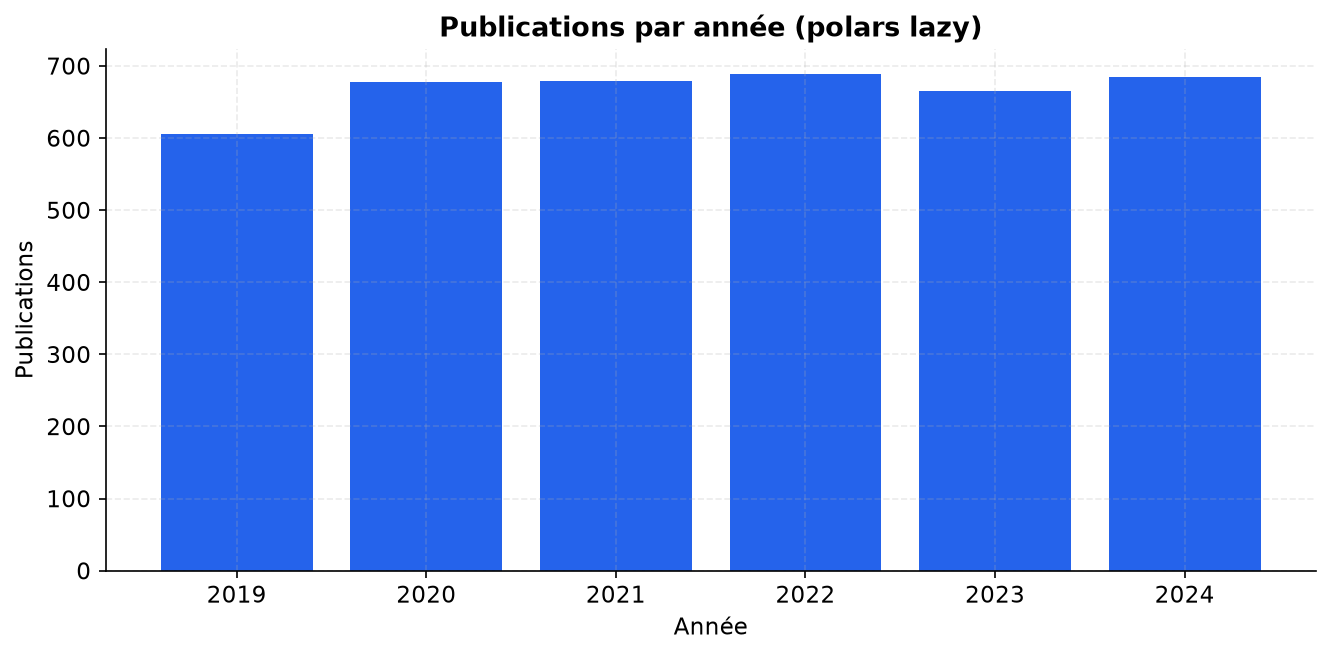

year,publications,citations_moy,taux_oa
i64,u32,f64,f64
2019,605,22.2,63.5
2020,678,20.2,65.9
2021,679,18.4,69.2
2022,689,12.9,66.5
2023,665,8.0,71.9
2024,684,4.4,71.9


In [3]:
lazy = (
    pl.scan_parquet(PARQUET)
    .group_by("year")
    .agg(
        pl.len().alias("publications"),
        pl.col("cited_by_count").mean().round(1).alias("citations_moy"),
        (100 * pl.col("is_oa").mean()).round(1).alias("taux_oa"),
    )
    .sort("year")
)
by_year = lazy.collect()
ax = new_axes("Publications par année (polars lazy)", xlabel="Année", ylabel="Publications")
ax.bar(by_year["year"].to_list(), by_year["publications"].to_list(), color=BRAND)
plt.tight_layout()
plt.show()
by_year

## 3. Équivalence des résultats (pandas vs polars vs DuckDB)

Les trois moteurs doivent donner le **même** résultat ; seules l'ergonomie et la
scalabilité diffèrent. On vérifie sur le décompte total et le taux d'OA.

In [4]:
pdf = pd.read_parquet(PARQUET)
checks = pd.DataFrame(
    {
        "moteur": ["pandas", "polars", "DuckDB"],
        "publications": [
            len(pdf),
            pl.scan_parquet(PARQUET).select(pl.len()).collect().item(),
            con.execute(f"SELECT COUNT(*) FROM '{PARQUET}'").fetchone()[0],
        ],
        "taux_oa_%": [
            round(100 * pdf["is_oa"].mean(), 1),
            round(pl.scan_parquet(PARQUET).select(100 * pl.col("is_oa").mean()).collect().item(), 1),
            round(con.execute(f"SELECT 100.0*AVG(CAST(is_oa AS INT)) FROM '{PARQUET}'").fetchone()[0], 1),
        ],
    }
)
checks

,moteur,publications,taux_oa_%
0,pandas,4000,68.2
1,polars,4000,68.2
2,DuckDB,4000,68.2


## 4. Mesure de temps indicative

Comparaison **à charge égale** : les trois moteurs exécutent exactement la même
tâche complète — **lire le fichier Parquet depuis le disque puis compter les
publications par année**. On répète plusieurs fois et l'on retient le meilleur
temps, pour limiter le bruit de mesure.

In [5]:
def best_ms(label: str, fn, repeats: int = 5) -> None:
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        fn()
        times.append(time.perf_counter() - start)
    print(f"{label:<18} : {min(times) * 1000:6.1f} ms (meilleur sur {repeats})")


# Même tâche complète pour les trois moteurs : lecture du Parquet + COUNT par
# année (pandas charge tout en mémoire ; polars/DuckDB lisent paresseusement et
# ne touchent que la colonne `year` — l'écart se creuse à l'échelle du Go).
best_ms("pandas", lambda: pd.read_parquet(PARQUET).groupby("year").size())
best_ms("polars (lazy)", lambda: pl.scan_parquet(PARQUET).group_by("year").agg(pl.len()).collect())
best_ms("DuckDB (SQL)", lambda: con.execute(f"SELECT year, COUNT(*) FROM '{PARQUET}' GROUP BY year").fetchall())

pandas             :    5.1 ms (meilleur sur 5)
polars (lazy)      :    8.1 ms (meilleur sur 5)
DuckDB (SQL)       :    3.6 ms (meilleur sur 5)


**Lecture.** Les trois moteurs produisent des résultats identiques. polars et
DuckDB apportent en plus la **scalabilité** (exécution paresseuse, colonnaire,
multi-cœurs, lecture sélective du Parquet) : la même logique d'agrégation
tiendrait sur un corpus national de plusieurs millions de notices sans changer
le code — ce qui préfigure la brique d'entrepôt du SID.